## Trần Nhật Trường
## MSSV: 24120486
## Bài tập về nhà buổi 2

### Cài đặt các thư viện cần thiết 

In [1]:
!pip  install -q numpy
!pip  install -q pandas
!pip  install -q matplotlib
!pip  install -q seaborn


### Import các thư viện cần thiết

In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Phần 1 - Thống kê mô tả và đặc trưng

### 1. Đọc dữ liệu, hiển thị 5 dòng, số dòng, số cột và kiểu dữ liệu của từng cột

In [3]:
df = sns.load_dataset('iris')
print(df.head())
print(df.shape)
print('Số dòng là:', df.shape[0])
print('Số cột là:', df.shape[1])
print(df.dtypes)

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
(150, 5)
Số dòng là: 150
Số cột là: 5
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object


- Nhận xét: Từ bảng thống kê trên có thể thấy đây là 1 bộ dữ liệu có 5 thuộc tính và có 150 mẫu dữ liệu. Trong đó có 4 thuộc tính có kiểu dữ liệu là float và 1 thuộc tính có kiểu dữ liệu là string. 

### 2. Mean, median, mode, var, std, min, max, Q1, Q3 và IQR

In [4]:
df_number = df.select_dtypes(include=['number'])
thongke = df_number.describe()
thongke.drop('50%', axis =0 , inplace = True)
thongke.drop('count', axis =0 , inplace = True)
thongke.loc['median'] = df_number.median()
thongke.loc['mode'] = df_number.mode().iloc[0]
thongke.loc['var'] = df_number.var()
thongke.loc['IQR'] = thongke.loc['75%'] - thongke.loc['25%']
print(thongke) 


        sepal_length  sepal_width  petal_length  petal_width
mean        5.843333     3.057333      3.758000     1.199333
std         0.828066     0.435866      1.765298     0.762238
min         4.300000     2.000000      1.000000     0.100000
25%         5.100000     2.800000      1.600000     0.300000
75%         6.400000     3.300000      5.100000     1.800000
max         7.900000     4.400000      6.900000     2.500000
median      5.800000     3.000000      4.350000     1.300000
mode        5.000000     3.000000      1.400000     0.200000
var         0.685694     0.189979      3.116278     0.581006
IQR         1.300000     0.500000      3.500000     1.500000


### 3. mean và std cho từng biến theo nhóm 

In [5]:
thongke_nhom = df.groupby('species').agg(['mean','std'])
print(thongke_nhom)

           sepal_length           sepal_width           petal_length  \
                   mean       std        mean       std         mean   
species                                                                
setosa            5.006  0.352490       3.428  0.379064        1.462   
versicolor        5.936  0.516171       2.770  0.313798        4.260   
virginica         6.588  0.635880       2.974  0.322497        5.552   

                     petal_width            
                 std        mean       std  
species                                     
setosa      0.173664       0.246  0.105386  
versicolor  0.469911       1.326  0.197753  
virginica   0.551895       2.026  0.274650  


- Nhận xét: Trong petal_length và petal_witdth thì trung bình của setosa nhỏ hơn rỏ rệt và độ lệch chuẩn của setosa trong petal_length cũng bé hơn rỏ rệt so với 2 cái còn lại. 

## Phần 2 - Phân phối xác suất


### 1. Histogram và KDE

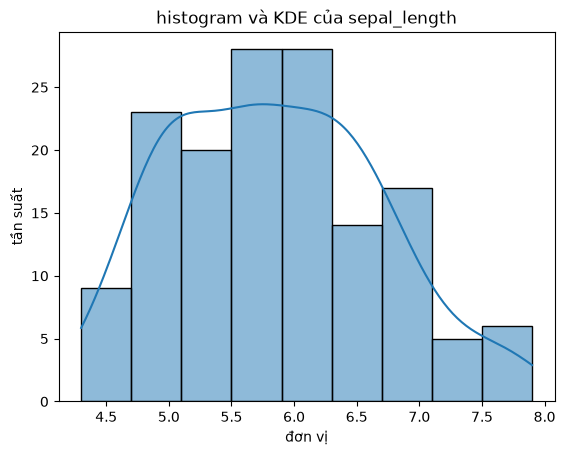

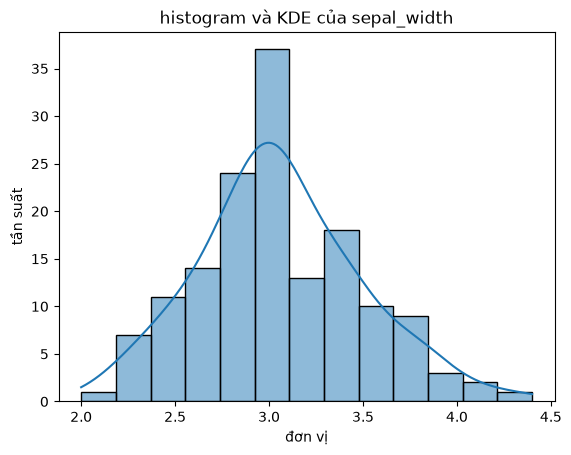

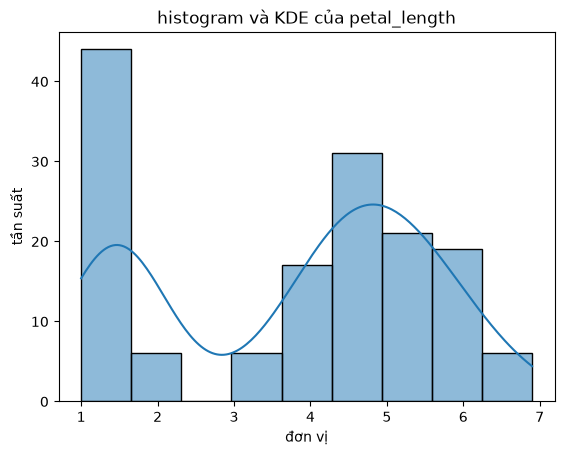

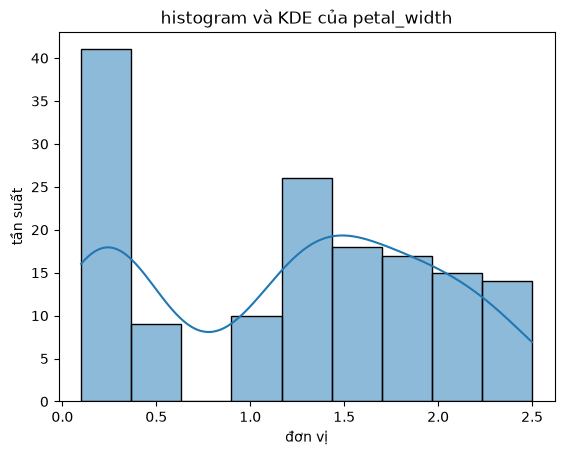

In [6]:
for column in df_number:
    sns.histplot(data=df, x=column, kde= True)
    plt.title(f'histogram và KDE của {column}')
    plt.xlabel('đơn vị')
    plt.ylabel('tần suất')
    plt.show()   


 #### Nhận xét:
- Phân phối của sepal_length gần với phân phối chuẩn, phân phối đều ra 2 bên và ở giữa nhiều nhất.
- Phân phối của sepal_width gần với phân phối chuẩn, phân phối đều ra 2 bên và ở giữa nhọn lên.
- phân phối của petal_length là phân phối nhiều đỉnh, ta có thể thấy 2 đỉnh, đỉnh thứ nhất ở giữa 1 và 2 đỉnh thứ 2 ở gần 5.
- Phân phối của petal_width là phân phối nhiều đỉnh, ta có thể thấy 2 đỉnh, đỉnh thứ nhất ở giữa 0 và 0.5 đỉnh thứ 2 ở 1.5.

### 2. Boxplot cho từng nhóm

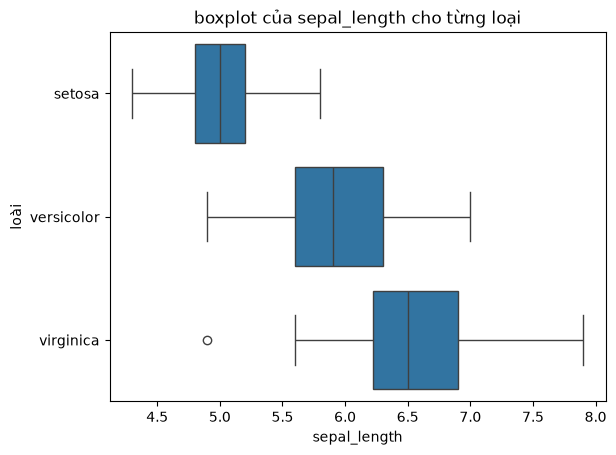

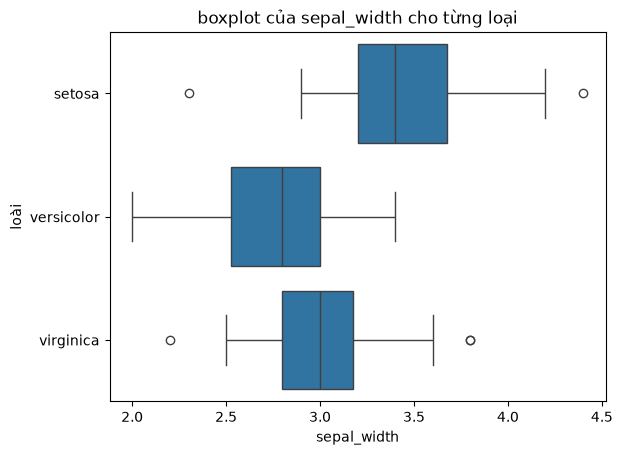

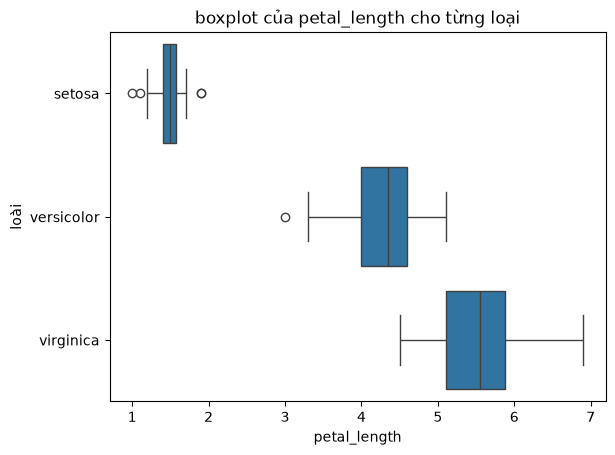

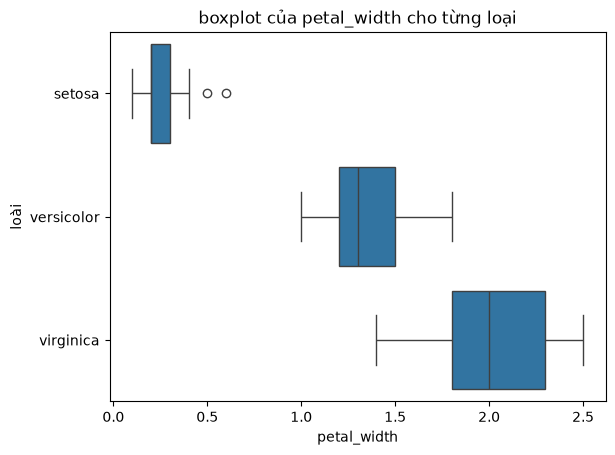

In [7]:
for column in df_number:
    sns.boxplot(data=df, x=column, y='species' )
    plt.title(f'boxplot của {column} cho từng loại')
    plt.xlabel(column)
    plt.ylabel('loài')
    plt.show()   


Nhận xét:
- Nhìn chung thì khoảng cách giữa các phần vị của loài setosa là đồng đều nhất, có độ chênh lệch ít hơn so với 2 cái còn lại, cho thấy giá trị của dữ liệu cách đều nhau và ổn định hơn 2 cái còn lại.
- 2 cái còn lại thì khoảng cách giữa các phân vị cách kém đồng đều hơn, cho thấy giá trị của dữ liệu bị nhảy vọt hoặc cách nhau không đều.

### 3. Mô phỏng

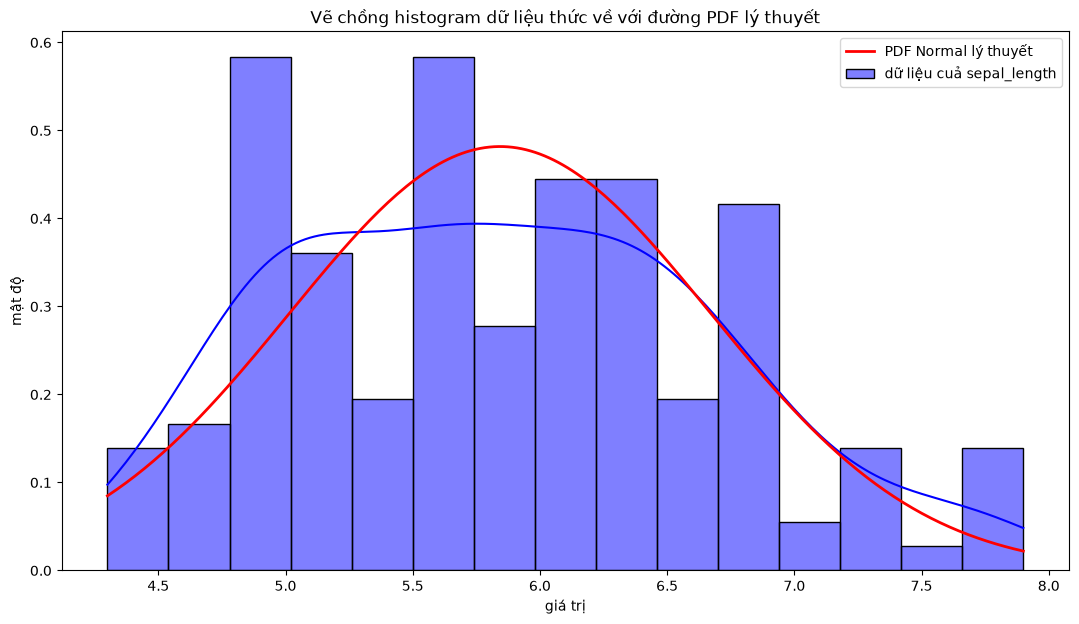

In [8]:
sepal_length = df['sepal_length']
sp_mean= sepal_length.mean()
sp_std = sepal_length.std()

sample_data=np.random.normal(loc=sp_mean,scale=sp_std,size= len(sepal_length))
x = np.linspace(sepal_length.min(), sepal_length.max(), 200)
pdf = 1 / (sp_std * np.sqrt(2 * np.pi)) * np.exp(-0.5 * ((x - sp_mean) / sp_std) ** 2)

plt.figure(figsize=(13,7))

sns.histplot(data=sepal_length,kde=True, stat= 'density',color= 'blue', label='dữ liệu cuả sepal_length', bins= 15)
plt.plot(x, pdf, color='red', linewidth=2, label='PDF Normal lý thuyết')

plt.title('Vẽ chồng histogram dữ liệu thức về với đường PDF lý thuyết')
plt.legend()
plt.xlabel('giá trị')
plt.ylabel('mật độ')
plt.show()


- Nhận xét: phân bố của dữ liệu thực tế tương đối khớp với dữ liệu được sinh ra. Phần giữa của dữ liệu thực tế phân bố rộng và thấp hơn so với đường PDF lý thuyết, phần bên trái có dốc cao hơn so với đường PDF lý thuyết. Dữ liệu mô tả có nhiều cụm hơn, có những phần bị lỏm hay quá ít giá trị ở đó.

## Phần 3 - Phần tích đa biến và tương quan

### 1. Hiệp phương sai và tương quan giữa các biến số

In [9]:
cov = df_number.cov()
corr = df_number.corr()
print(cov)
print(corr)

              sepal_length  sepal_width  petal_length  petal_width
sepal_length      0.685694    -0.042434      1.274315     0.516271
sepal_width      -0.042434     0.189979     -0.329656    -0.121639
petal_length      1.274315    -0.329656      3.116278     1.295609
petal_width       0.516271    -0.121639      1.295609     0.581006
              sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.117570      0.871754     0.817941
sepal_width      -0.117570     1.000000     -0.428440    -0.366126
petal_length      0.871754    -0.428440      1.000000     0.962865
petal_width       0.817941    -0.366126      0.962865     1.000000


### 2. heatmap

<Axes: >

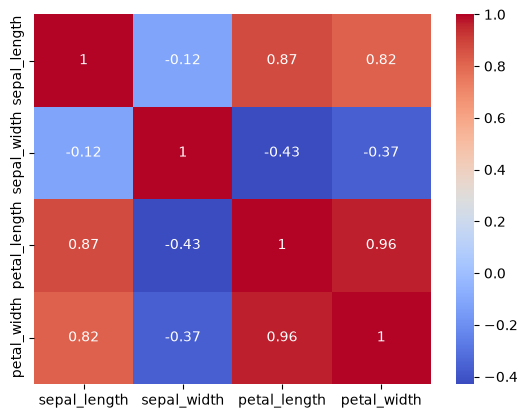

In [10]:
sns.heatmap(data=corr, annot=True, cmap='coolwarm')

- cặp có tương quan mạnh nhất trừ tương quan với chính nó là giữa petal_length và petal_width. Có chỉ số corr là 0.96 gần như 1 cái tăng hoặc giảm thì cái kia cũng vậy. Vì 2 cái này là chiều dài và chiều rộng của cùng 1 bộ phận nên có thể nói khi chiều dài tăng thì chiều rộng cũng vậy nên phân bố về tỉ lệ ngang và dọc của petal của hoa iris có thể khá ổn định.
- Có đa cộng tuyển ở mối tương quan giữa petal_length với sepal_length và petal_width và sepal_length. Cả 2 cái đều có tương quan trên 0.8 và đều liên quan đến petal_width. Ngoài ra có dấu hiệu giữa quan hệ giữa petal_length với petal_width và sepal_length với petal_width. Cả 2 đều có tương quan trên 0.8 và đều liên quan đến petal_width.

### 3. Pairplot

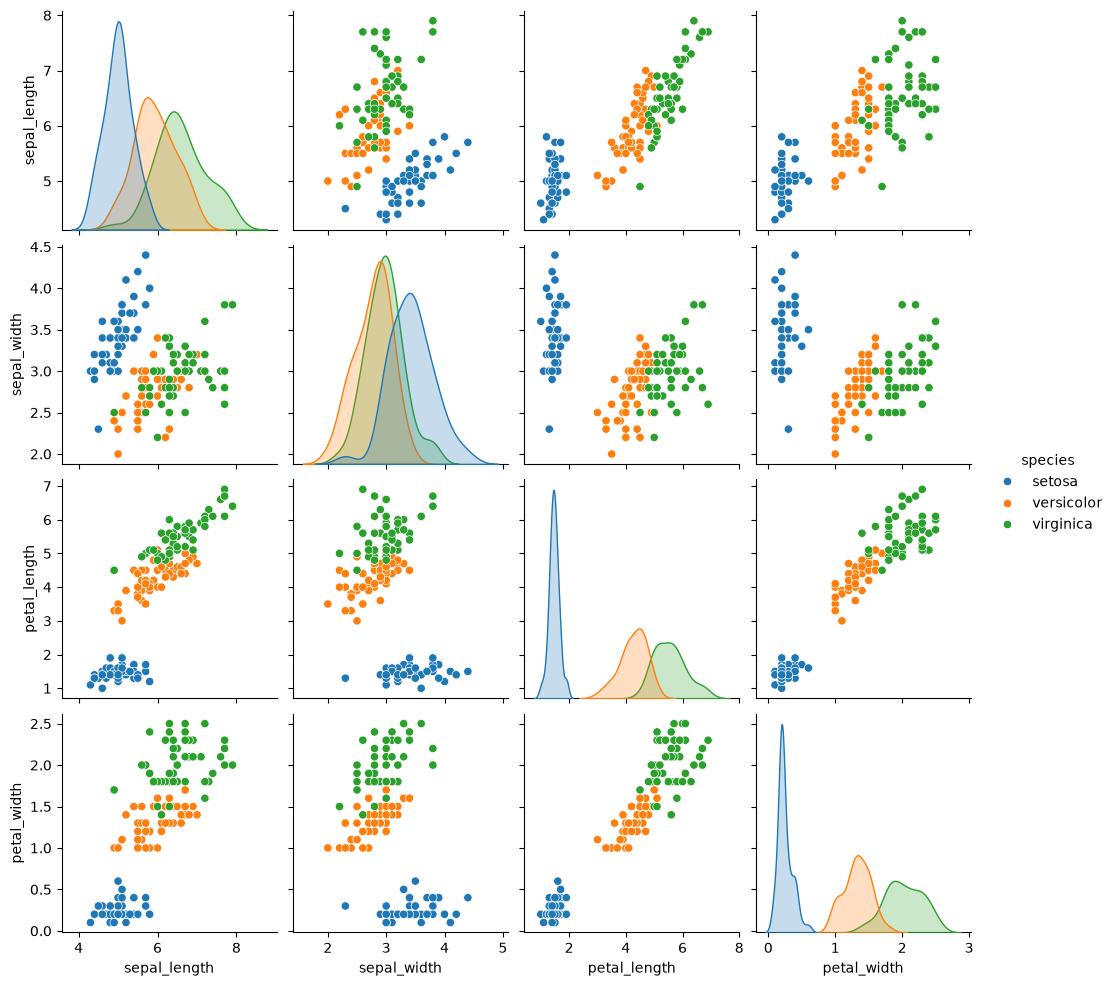

In [11]:
sns.pairplot(df,hue='species')

- Nhận xét: Mối quan hệ giữa petal_length và petal_width có mối quan hệ tuyến tính mạnh, dữ liệu tạo thành đường chéo. Ngoài ra sepal_length với petal_length và sepal_length với petal_width cũng khá mạnh. sepal_width với các thành phần khác tạo thành từng mảng thay vì các đường cho thấy tương quan khá yếu.

## Phần 4 - Xác suất và định lí Bayes

### 1. tính xác xuất

In [12]:
def P_B_given_pos(P_B, P_pos_givenB, P_pos_givnNB):
    result = (P_pos_givenB*P_B)/(P_pos_givenB*P_B+P_pos_givnNB*(1-P_B))
    return round(result, 4)

P_B= 0.01
P_pos_givenB = 0.99
P_pos_givnNB = 0.05
print(P_B_given_pos(P_B,P_pos_givenB,P_pos_givnNB))

0.1667


### 2. Khảo sát

[0.001, 0.0051, 0.0091, 0.0132, 0.0172, 0.0213, 0.0254, 0.0294, 0.0335, 0.0376, 0.0416, 0.0457, 0.0497, 0.0538, 0.0579, 0.0619, 0.066, 0.07, 0.0741, 0.0782, 0.0822, 0.0863, 0.0903, 0.0944, 0.0985, 0.1025, 0.1066, 0.1107, 0.1147, 0.1188, 0.1228, 0.1269, 0.131, 0.135, 0.1391, 0.1431, 0.1472, 0.1513, 0.1553, 0.1594, 0.1634, 0.1675, 0.1716, 0.1756, 0.1797, 0.1838, 0.1878, 0.1919, 0.1959, 0.2]
[0.0194, 0.0915, 0.1542, 0.2092, 0.2579, 0.3012, 0.3401, 0.3751, 0.4069, 0.4358, 0.4623, 0.4866, 0.5089, 0.5296, 0.5487, 0.5665, 0.5831, 0.5986, 0.6131, 0.6267, 0.6395, 0.6515, 0.6629, 0.6736, 0.6838, 0.6934, 0.7026, 0.7113, 0.7195, 0.7274, 0.7349, 0.7421, 0.749, 0.7555, 0.7618, 0.7679, 0.7736, 0.7792, 0.7845, 0.7897, 0.7946, 0.7994, 0.8039, 0.8084, 0.8126, 0.8168, 0.8207, 0.8246, 0.8283, 0.8319]


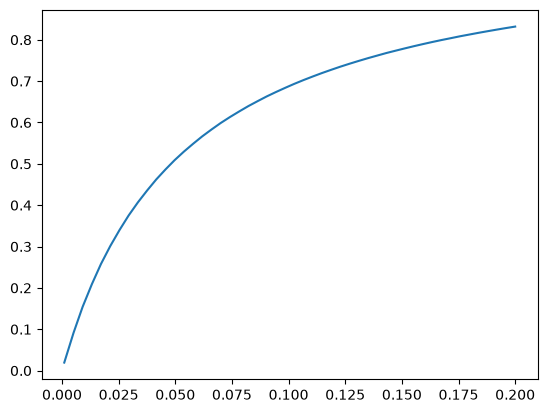

In [13]:
start_EB = 0.001
bump = (0.2-0.001)/49
P_B_given_pos_set = []
EB_set=[]
for i in range(50):
    P_B_given_pos_set.append(P_B_given_pos(start_EB,P_pos_givenB,P_pos_givnNB))
    # start_EB = round(start_EB,4)
    EB_set.append(round(start_EB,4))
    start_EB+=bump
print(EB_set)
print(P_B_given_pos_set)

plt.plot(EB_set,P_B_given_pos_set )


- Khi tỉ lệ mắc bệnh càng cao thì tỉ lệ dự đoán đúng dương tính với 1 người bị bệnh lại càng cao vì ta có công thức P(B|+) = (P(+|B)*P(B)) / (P(+|B)*P(B) + P(+|~B)*P(~B)) khi P(B) tăng thì P(+|B)*P(B) tăng vì P(+|B) cố định, lúc này cả tử và mẫu đều chứa cái này nên cả mẫu và tử đều tăng cùng 1 lượng nên không làm ảnh hưởng đến P(B|+), nhưng ở mẫu ta có P(+|~B)*P(~B) sẽ giảm vì P(+|~B) là cố định và khi P(B) tăng thì P(~B) sẽ giảm (vì P(~B)= 1 - P(B)) dẫn tới P(+|~B)*P(~B) giảm. Vì mẫu giảm nên P(B) sẽ tăng.
- Hay về mặc thực tế: Khi 1 bênh hiếm thì đa số người sẽ không bị mắc bệnh, khi đó chỉ với số nhỏ % tỉ lệ dương tính giả thôi cũng tạo ra con số dương tính giả lớn so với tỉ lệ dương tính thật vì số người bị bệnh rất ít.